# Carga y Visualización de Insumos ODS CDMX

Carga inicial de insumos crudos. Lectura de archivos comprimidos, inspección básica de datos y visualización de geometrías para capas espaciales.

**Insumos cargados:**

1. Censo de Población y Vivienda 2020 (Densidad)
2. Catastro CDMX (Densidad)
3. DENUE (Densidad)
4. Catálogo de Colonias (Proximidad)
5. Vialidades Primarias (Proximidad)
6. Vialidades de Acceso Controlado (Proximidad)
7. Información Vial - Infovial (Proximidad)
8. Infraestructura Ciclista - Proxy Ecobici (Proximidad)

In [3]:
# Importación de librerias
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import zipfile

def cargarCapaComprimida(rutaZip):
    """Carga una capa espacial desde un archivo ZIP buscando el .shp interno."""
    rutaZip = Path(rutaZip).resolve()
    with zipfile.ZipFile(rutaZip, 'r') as z:
        # Buscar archivos .shp, excluyendo carpetas ocultas de macOS
        archivosShp = [f for f in z.namelist() if f.endswith('.shp') and '__MACOSX' not in f]
        if not archivosShp:
            archivosShp = [f for f in z.namelist() if (f.endswith('.geojson') or f.endswith('.json') or f.endswith('.gpkg')) and '__MACOSX' not in f]
        
        if archivosShp:
            # El protocolo zip:// en geopandas requiere la ruta absoluta al zip seguida de ! y la ruta interna
            return gpd.read_file(f"zip://{rutaZip.as_posix()}!{archivosShp[0]}")
        else:
            raise FileNotFoundError(f"No se encontró un archivo espacial soportado en {rutaZip}")

# Configuración de rutas
rutaInsumos = Path("../datos/crudos/insumos").resolve()
rutaVial = rutaInsumos / "vial"
rutaCatastro = rutaInsumos / "catastro"
rutaProcesados = Path("../datos/procesados").resolve()

os.makedirs(rutaProcesados, exist_ok=True)

print(f"Ruta base absoluta: {rutaInsumos}")
print("Configuración inicial completada.")

Ruta base absoluta: /home/arturo/trio-tristeza-ods/datos/crudos/insumos
Configuración inicial completada.


## Insumos variable densidad

### 1. Censo de Población y Vivienda 2020 (ITER)

In [2]:
rutaCenso = rutaInsumos / "iter_09_cpv2020_csv.zip"
with zipfile.ZipFile(rutaCenso, 'r') as z:
    archivoDatos = [f for f in z.namelist() if 'conjunto_de_datos' in f and f.endswith('.csv')][0]
    censoPoblacion2020 = pd.read_csv(z.open(archivoDatos))

censoPoblacion2020.columns = censoPoblacion2020.columns.str.strip().str.upper()
if 'POBTOT' in censoPoblacion2020.columns:
    print(f"Población total registrada: {censoPoblacion2020.iloc[0]['POBTOT']}")
display(censoPoblacion2020.head())

Población total registrada: 9209944


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,9,Ciudad de México,0,Total de la entidad Ciudad de México,0,Total de la Entidad,NaN,NaN,NaN,9209944,...,2536523,2084156,1290811,957162,568827,46172,77272,561128,10528,*
1,9,Ciudad de México,0,Total de la entidad Ciudad de México,9998,Localidades de una vivienda,NaN,NaN,NaN,320,...,67,23,17,8,8,9,14,52,5,*
2,9,Ciudad de México,0,Total de la entidad Ciudad de México,9999,Localidades de dos viviendas,NaN,NaN,NaN,364,...,89,27,22,6,4,10,15,72,3,*
3,9,Ciudad de México,2,Azcapotzalco,0,Total del Municipio,NaN,NaN,NaN,432205,...,123961,105899,66399,50965,31801,1661,2869,22687,322,*
4,9,Ciudad de México,2,Azcapotzalco,1,Azcapotzalco,"99°11'03.698"" W","19°29'02.770"" N",2244.0,432205,...,123961,105899,66399,50965,31801,1661,2869,22687,322,12


### 2. Catastro CDMX

In [3]:
rutaCatastroUnificado = Path("../datos/procesados/catastro_unificado_cdmx.gpkg").resolve()
os.makedirs(rutaCatastroUnificado.parent, exist_ok=True)

if rutaCatastroUnificado.exists():
    print(f"Cargando catastro unificado desde: {rutaCatastroUnificado}")
    catastroCdmx = gpd.read_file(rutaCatastroUnificado)
else:
    print("Archivo unificado no encontrado. Iniciando proceso de unificación (16 alcaldías)...")
    listaCapasCatastro = []
    for archivo in sorted(os.listdir(rutaCatastro)):
        if archivo.endswith(".zip"):
            rutaZip = rutaCatastro / archivo
            try:
                print(f"  - Procesando: {archivo}")
                capaAlcaldia = cargarCapaComprimida(rutaZip)
                # Limpieza de columnas conflictivas (como 'fid' de GeoPackage)
                if 'fid' in capaAlcaldia.columns: capaAlcaldia = capaAlcaldia.drop(columns=['fid'])
                listaCapasCatastro.append(capaAlcaldia)
            except Exception as e:
                print(f"  ! Error al cargar {archivo}: {e}")

    if listaCapasCatastro:
        print("Concatenando y guardando archivo unificado...")
        # Asegurar mismo CRS antes de concatenar
        crsRef = listaCapasCatastro[0].crs
        listaCapasCatastro = [c.to_crs(crsRef) for c in listaCapasCatastro]
        
        catastroCdmx = pd.concat(listaCapasCatastro, ignore_index=True)
        catastroCdmx = gpd.GeoDataFrame(catastroCdmx, crs=crsRef)
        
        # Guardar para futuras cargas rápidas
        catastroCdmx.to_file(rutaCatastroUnificado, driver='GPKG')
        print(f"¡Éxito! Catastro unificado guardado en: {rutaCatastroUnificado}")
    else:
        catastroCdmx = None

if catastroCdmx is not None:
    print(f"Total de predios en catastro: {len(catastroCdmx)}")
    display(catastroCdmx.head(3))
else:
    print("No se cargaron capas de catastro.")

Cargando catastro unificado desde: /home/arturo/trio-tristeza-ods/datos/procesados/catastro_unificado_cdmx.gpkg
Total de predios en catastro: 1089684


,geometry
0,"POLYGON ((478791.018 2145255.261, 478795.363 2..."
1,"POLYGON ((478781.756 2145254.191, 478784.677 2..."
2,"POLYGON ((478780.5 2145189.284, 478781.751 214..."


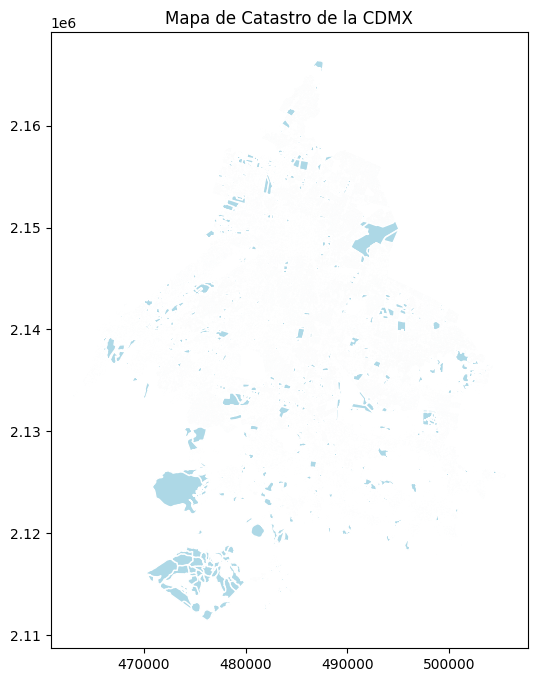

In [4]:
catastroCdmx.plot(figsize=(8, 8), color='lightblue', edgecolor='white')
plt.title("Mapa de Catastro de la CDMX")
plt.show()

### 3. Censo de Población por Manzanas (CPV 2020)

In [7]:
rutaCensoManzanasTabular = rutaInsumos / "Censo de Población 2020 nacional Manzanas.zip"
rutaManzanasEspacial = rutaInsumos / "poligono_manzanas_cdmx.zip"
rutaExportManzanas = rutaProcesados / "manzanas_cdmx_poblacion.gpkg"

cols_pob = ['POBTOT', 'POBFEM', 'POBMAS']
cols_edad = ['P_0A2', 'P_3A5', 'P_6A11', 'P_12A14', 'P_15A17', 'P_18A24', 'P_60YMAS']
cols_interes = ['ClaveMan'] + cols_pob + cols_edad

with zipfile.ZipFile(rutaCensoManzanasTabular, 'r') as z:
    archivoCsv = [f for f in z.namelist() if f.endswith('.csv') and 'diccionario' not in f.lower()][0]
    
    listaFiltrada = []
    for chunk in pd.read_csv(z.open(archivoCsv), chunksize=100000, low_memory=False, encoding='latin1'):
        chunk.columns = [c.replace('ï»¿', '').strip() for c in chunk.columns]
        filtro_cdmx = chunk[chunk['ClaveEnt'] == 9].copy()
        if not filtro_cdmx.empty:
            # Limpieza de datos numéricos (manejo de '*' de INEGI)
            for col in cols_pob + cols_edad:
                filtro_cdmx[col] = pd.to_numeric(filtro_cdmx[col], errors='coerce').fillna(0)
            listaFiltrada.append(filtro_cdmx[cols_interes])
            
    censoManzanasCdmx = pd.concat(listaFiltrada, ignore_index=True)

geometriaManzanas = cargarCapaComprimida(rutaManzanasEspacial)

censoManzanasCdmx['CVEGEO'] = censoManzanasCdmx['ClaveMan'].astype(str).str.zfill(16)
geometriaManzanas['CVEGEO'] = geometriaManzanas['CVEGEO'].astype(str).str.strip().str.zfill(16)

manzanasUnificadas = geometriaManzanas.merge(censoManzanasCdmx, on='CVEGEO', how='inner')

print(f"Exportando {len(manzanasUnificadas)} manzanas unificadas a GeoPackage...")
manzanasUnificadas.to_file(rutaExportManzanas, driver='GPKG')

print(f"Archivo guardado en: {rutaExportManzanas}")
display(manzanasUnificadas[['CVEGEO', 'POBTOT', 'POBFEM', 'POBMAS', 'geometry']].head())

Exportando 63174 manzanas unificadas a GeoPackage...
Archivo guardado en: /home/arturo/trio-tristeza-ods/datos/procesados/manzanas_cdmx_poblacion.gpkg


,CVEGEO,POBTOT,POBFEM,POBMAS,geometry
0,0901000010898031,93,56.0,37.0,"POLYGON ((-99.22982 19.35939, -99.23058 19.358..."
1,0901000012269024,6,0.0,0.0,"POLYGON ((-99.2184 19.36539, -99.21851 19.3653..."
2,0901000011472068,124,66.0,58.0,"POLYGON ((-99.24577 19.37776, -99.24593 19.377..."
3,0901000011824024,340,177.0,163.0,"POLYGON ((-99.22371 19.34729, -99.22378 19.347..."
4,0901000012377004,82,41.0,41.0,"POLYGON ((-99.2114 19.36991, -99.21136 19.3698..."


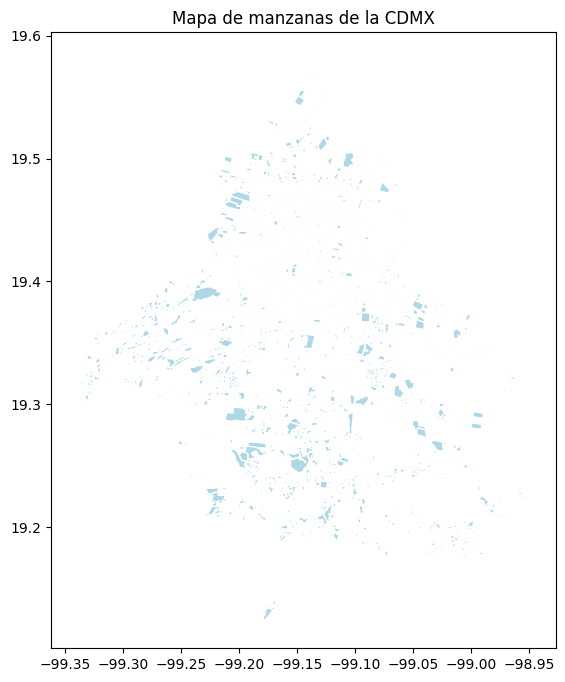

In [6]:
manzanasUnificadas.plot(figsize=(8, 8), color='lightblue', edgecolor='white')
plt.title("Mapa de manzanas de la CDMX")
plt.show()

### 4. DENUE (Directorio Estadístico de Unidades Económicas)

In [6]:
rutaDenue = rutaInsumos / "denue_cdmx.zip"
try:
    unidadesEconomicasDenue = cargarCapaComprimida(rutaDenue)
except:
    # Si falla la carga espacial, intentar como CSV comprimido
    unidadesEconomicasDenue = pd.read_csv(rutaDenue, compression='zip', encoding='latin1')

print(f"Registros cargados: {len(unidadesEconomicasDenue)}")
display(unidadesEconomicasDenue.head())

Registros cargados: 17216


,nmbr_st,rzn_scl,fech_lt,ctgr_ct,activdd,prsns_c,tp_mprs,tp_cnt_,cntr_cm,tp_ndd_,direccn,colonia,alcaldi,telefon,crr_lct,pagn_wb,geometry
0,.SERVICIO TECNICO Y CONSUMIBLES,NaN,2014-12-01,Otros,Revistas y periódicos,0 a 5 personas,Microempresa,NaN,NaN,Fijo,CALLE REGINA EXT. 4 C.P. 6090,CENTRO VI,CUAUHTEMOC,NaN,NaN,NaN,POINT (-99.12952 19.4269)
1,0023 OFICINA CENTRAL MEXICO,BIMBO SA DE CV,2010-07-01,"Ropa, calzado y textiles",Calzado,251 y más personas,Mediana empresa,NaN,NaN,Fijo,AVENIDA SAN PABLO XALPA EXT. 520 C.P. 2200,SAN MARTIN XOCHINAHUAC (PBLO),AZCAPOTZALCO,NaN,NaN,www.bimbo.com.mx,POINT (-99.18303 19.50546)
2,1002 AZCAPOTZALCO,BIMBO SA DE CV,2010-07-01,"Ropa, calzado y textiles",Calzado,251 y más personas,Mediana empresa,NaN,NaN,Fijo,AVENIDA SAN PABLO XALPA EXT. 520 INT. 0,SAN MARTIN XOCHINAHUAC (PBLO),AZCAPOTZALCO,NaN,NaN,NaN,POINT (-99.18303 19.50546)
3,11:11,NaN,2019-11-01,Otros,Intermediación de comercio al por mayor exclus...,0 a 5 personas,Microempresa,NaN,NaN,Fijo,CALZADA CALZADA DE TLALPAN EXT. 3196 INT. 2 C....,VIEJO EJIDO SANTA URSULA COAPA,COYOACAN,NaN,NaN,NaN,POINT (-99.14127 19.30935)
4,12 DE ARANDA,NaN,2014-12-01,"Materiales de construcción, herramientas y maq...",Maquinaria y equipo para otros servicios y par...,0 a 5 personas,Microempresa,NaN,NaN,Fijo,CALLE ARANDA EXT. 12 C.P. 6050,CENTRO VIII,CUAUHTEMOC,NaN,el12dearanda@live.com..mx,NaN,POINT (-99.14258 19.43102)


## Insumos variable proximidad

### 4. Catálogo de Colonias

Columnas: ['cve_ent', 'entidad', 'cve_alc', 'alc', 'cve_col', 'colonia', 'clasif', 'geometry']


,cve_ent,entidad,cve_alc,alc,cve_col,colonia,clasif,geometry
0,09,Ciudad de México,002,Azcapotzalco,002-001,Aguilera,Colonia,"POLYGON ((-99.15913 19.47261, -99.15906 19.473..."
1,09,Ciudad de México,002,Azcapotzalco,002-002,Aldana,Colonia,"POLYGON ((-99.15171 19.46819, -99.15157 19.469..."
2,09,Ciudad de México,002,Azcapotzalco,002-003,Ampliacion Cosmopolita,Colonia,"POLYGON ((-99.16362 19.47223, -99.16334 19.472..."
3,09,Ciudad de México,002,Azcapotzalco,002-004,Ampliacion Del Gas,Colonia,"POLYGON ((-99.16152 19.46774, -99.16152 19.468..."
4,09,Ciudad de México,002,Azcapotzalco,002-005,Ampliacion Petrolera,Colonia,"POLYGON ((-99.19762 19.48231, -99.19649 19.485..."


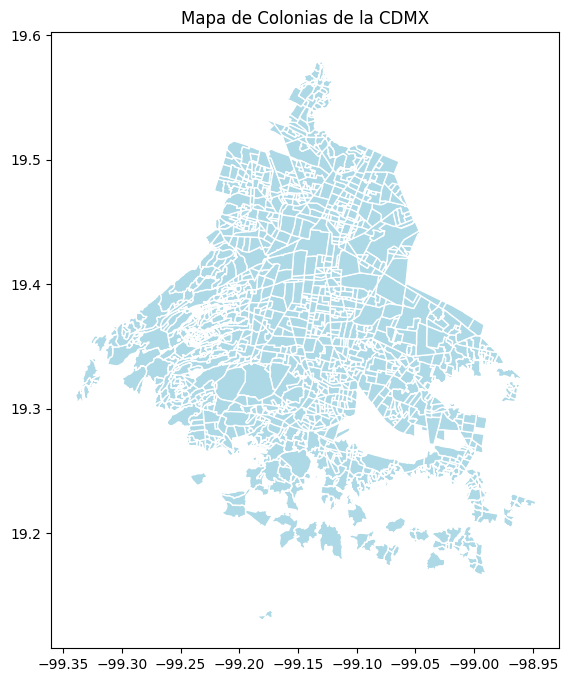

In [7]:
rutaColonias = rutaInsumos / "poligonos_colonias_cdmx.zip"
catalogoColonias = cargarCapaComprimida(rutaColonias)

print(f"Columnas: {catalogoColonias.columns.tolist()}")
display(catalogoColonias.head())
catalogoColonias.plot(figsize=(8, 8), color='lightblue', edgecolor='white')
plt.title("Mapa de Colonias de la CDMX")
plt.show()

### 5. Vialidades Primarias

,ID_VIA,NOMBRE,ID_NOM,NOMENCLAT,TIPO_VIA,CARRILES,NIVEL,CIRCULA,ALCALDIA,geometry
0,88,Ruta 41,1,Casa del Obrero Mundial,Vía primaria,2,0,Un sentido,Benito Juárez,"LINESTRING (482974.538 2145216.094, 483076.991..."
1,20,Eje 2 Poniente,2,Casa del Obrero Mundial,Vía primaria,2,0,Un sentido,Benito Juárez,"LINESTRING (483076.991 2145232.504, 483206.739..."
2,45,Eje 10A Sur,1,Avenida Copilco,Vía primaria,2,0,Un sentido,Coyoacán,"LINESTRING (480054.511 2138294.399, 480045.45 ..."
3,45,Eje 10A Sur,1,Avenida Copilco,Vía primaria,2,0,Un sentido,Coyoacán,"LINESTRING (480054.511 2138294.399, 480048.574..."
4,45,Eje 10A Sur,1,Avenida Copilco,Vía primaria,4,0,Un sentido,Coyoacán,"LINESTRING (480617.823 2138188.2, 480599.087 2..."


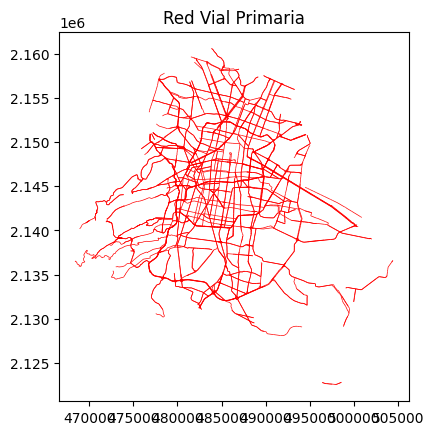

In [11]:
rutaVialPrimaria = rutaVial / "1ra_red_vial_primaria_acceso_controlado.zip"
vialidadesPrimarias = cargarCapaComprimida(rutaVialPrimaria)
display(vialidadesPrimarias.head())
vialidadesPrimarias.plot(color='red', linewidth=0.5)
plt.title("Red Vial Primaria")
plt.show()

### 6. Vialidades de Acceso Controlado

,Name,tipo_vial,entre,id_vial,geometry
0,AQUILES SERDAN,VIALIDADES DE ACCESO CONTROLADO,CALZ. DE LAS ARMAS Y CALZ. MEXICO-TACUBA,1,"LINESTRING Z (477895.342 2157146.486 0, 477901..."
1,AV. GRAN CANAL,VIALIDADES DE ACCESO CONTROLADO,PERIFERICO Y CIRCUITO INTERIOR,2,"LINESTRING Z (491812.388 2156590.469 0, 491709..."
2,CALZ. DE TLALPAN,VIALIDADES DE ACCESO CONTROLADO,INSURGENTES Y VIADUCTO,3,"LINESTRING Z (482384.662 2131706.277 0, 482387..."
3,CALZ. IGNACIO ZARAGOZA,VIALIDADES DE ACCESO CONTROLADO,EJE 3 ORIENTE Y EJE 8 SUR,4,"LINESTRING Z (487887.915 2148433.855 0, 487890..."
4,CIRCUITO INTERIOR,VIALIDADES DE ACCESO CONTROLADO,EJE 4 SUR Y EJE 4 SUR,5,"LINESTRING Z (480950.27 2146500.964 0, 481170...."


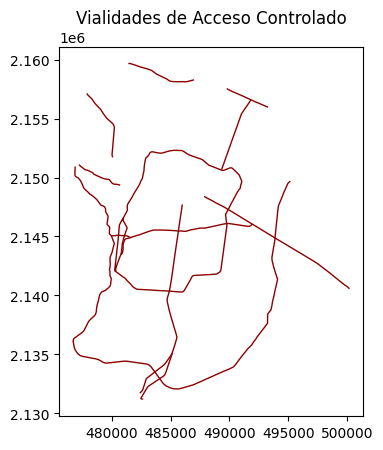

In [12]:
rutaAccesoControlado = rutaVial / "vialidades-de-acceso-controlado.zip"
vialidadesAccesoControlado = cargarCapaComprimida(rutaAccesoControlado)
display(vialidadesAccesoControlado.head())
vialidadesAccesoControlado.plot(color='darkred', linewidth=1)
plt.title("Vialidades de Acceso Controlado")
plt.show()

### 7. Información Vial (Infovial)

In [13]:
rutaVelocidad = rutaVial / "201601_velocidad_limpio.csv"
informacionVialVelocidad = pd.read_csv(rutaVelocidad)
display(informacionVialVelocidad.head())

,id,fecha,vialidad,sentido,ubicacion,velocidad
0,1,2016-01-01 00:00,EJE 2 SUR,PONIENTE-ORIENTE,JUAN ESCUTIA - CHAPULTEPEC,46.78
1,2,2016-01-01 00:00,EJE 2 SUR,PONIENTE-ORIENTE,YUCATÁN - ÁLVARO OBREGÓN,46.76
2,3,2016-01-01 00:00,EJE 2 SUR,PONIENTE-ORIENTE,MONTERREY - TONALÁ,46.09
3,4,2016-01-01 00:00,EJE 2 SUR,PONIENTE-ORIENTE,MÉRIDA - FRONTERA,43.56
4,5,2016-01-01 00:00,EDUARDO MOLINA,SUR-NORTE,CALLE 312 - 310,0.00


### 8. Infraestructura Ciclista (Proxy Ecobici)

,ID_TRAMO,ID_PROY,NOMBRE,TIPO_IC,ALCALDIA,VIALIDAD,TIPO_VIA,TIPO_CONEC,ESTADO,EJECUTOR,A_INICIO,A_TERMINO,LONG_KM,geometry
0,105,22,Ciclovía Av. Chapultepec,Carril bus bici,Cuauhtémoc,Eje 1A Sur Avenida José Maria Izazaga,Primaria,Local,Requiere mantenimiento,Gobierno Central,ND,2012,0.94,"LINESTRING Z (486028.041 2147972.724 0, 485928..."
1,106,22,Ciclovía Av. Chapultepec,Carril bus bici,Cuauhtémoc,Eje 1A Sur Arcos de Belen,Primaria,Local,Requiere mantenimiento,Gobierno Central,ND,2012,0.73,"LINESTRING Z (485092.837 2148074.453 0, 485085..."
2,125,23,Bus Bici Eje 7 Sur,Carril bus bici,Benito Juárez,Eje 7 Sur Municipio Libre,Primaria,Local,En operacion,Gobierno Central,ND,2012,0.86,"LINESTRING Z (483528.621 2141817.371 0, 483335..."
3,126,23,Bus Bici Eje 7 Sur,Carril bus bici,Benito Juárez,Eje 7 Sur Felix Cuevas,Primaria,Local,En operacion,Gobierno Central,ND,2012,1.52,"LINESTRING Z (482689.685 2141853.962 0, 482438..."
4,127,23,Bus Bici Eje 7 Sur,Carril bus bici,Benito Juárez,Eje 7 Sur Extremadura,Primaria,Local,En operacion,Gobierno Central,ND,2012,0.96,"LINESTRING Z (481206.682 2142197.306 0, 481195..."


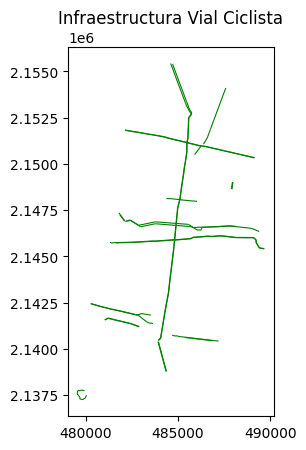

In [14]:
rutaCiclista = rutaInsumos / "infraestructura_vial_ciclista.zip"
infraestructuraCiclista = cargarCapaComprimida(rutaCiclista)
display(infraestructuraCiclista.head())
infraestructuraCiclista.plot(color='green', linewidth=0.8)
plt.title("Infraestructura Vial Ciclista")
plt.show()